In [1]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import astropy.units as u
import numpy as np

In [2]:
# define the data

pickle_read_name = '/Users/eckhartspalding/Downloads/kira/output_channels_dc0pt2.pkl'

In [3]:
# read in

read_in = Path(pickle_read_name)
with read_in.open("rb") as f:
    output_channels = pickle.load(f)

In [4]:
# print data cols (should be the same names in each of the four channels)

for channel_name in output_channels:
    print('-------------------------------')
    print('CHANNEL NAME:')
    print(channel_name)
    print('-------------------------------')
    print('CHANNEL COLS:')
    for colname in output_channels[channel_name].keys():
        print(colname)
    #print(output_channels[channel_name])
    print('-------------------------------')

-------------------------------
CHANNEL NAME:
output_1_bright
-------------------------------
CHANNEL COLS:
wavel_bin_num
wavel_bin_center
wavel_bin_width
n_pix_per_wavel_bin
instrum_dark_current_rms_for_wavel_bin_and_integration_adu_tot
instrum_read_noise_rms_for_wavel_bin_and_integration_adu_tot
astro_star_flux_adu_for_wavel_bin_and_integration_tot
astro_exoplanet_model_10pc_flux_adu_for_wavel_bin_and_integration_tot
astro_exozodiacal_flux_adu_for_wavel_bin_and_integration_tot
astro_zodiacal_flux_adu_for_wavel_bin_and_integration_tot
-------------------------------
-------------------------------
CHANNEL NAME:
output_2_bright
-------------------------------
CHANNEL COLS:
wavel_bin_num
wavel_bin_center
wavel_bin_width
n_pix_per_wavel_bin
instrum_dark_current_rms_for_wavel_bin_and_integration_adu_tot
instrum_read_noise_rms_for_wavel_bin_and_integration_adu_tot
astro_star_flux_adu_for_wavel_bin_and_integration_tot
astro_exoplanet_model_10pc_flux_adu_for_wavel_bin_and_integration_tot
ast

In [5]:
# we just care about dark_3 channel for now

channel_dark_3 = output_channels['output_3_dark']

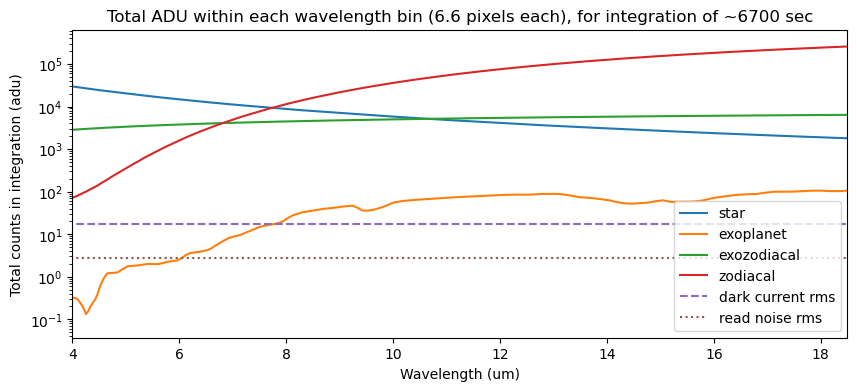

In [6]:
# plot the total ADU in each wavelength bin, given a set integration time (each wavelength bin encompasses 6.6 pixels in this example)

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(channel_dark_3['wavel_bin_center'], channel_dark_3['astro_star_flux_adu_for_wavel_bin_and_integration_tot'], label='star')
ax.plot(channel_dark_3['wavel_bin_center'], channel_dark_3['astro_exoplanet_model_10pc_flux_adu_for_wavel_bin_and_integration_tot'], label='exoplanet')
ax.plot(channel_dark_3['wavel_bin_center'], channel_dark_3['astro_exozodiacal_flux_adu_for_wavel_bin_and_integration_tot'], label='exozodiacal')
ax.plot(channel_dark_3['wavel_bin_center'], channel_dark_3['astro_zodiacal_flux_adu_for_wavel_bin_and_integration_tot'], label='zodiacal')
ax.plot(channel_dark_3['wavel_bin_center'], channel_dark_3['instrum_dark_current_rms_for_wavel_bin_and_integration_adu_tot'], linestyle='--', label='dark current rms')
ax.plot(channel_dark_3['wavel_bin_center'], channel_dark_3['instrum_read_noise_rms_for_wavel_bin_and_integration_adu_tot'], linestyle=':', label='read noise rms')

ax.set_xlim([4,18.5])
ax.set_yscale('log')
plt.xlabel(f"Wavelength ({channel_dark_3['wavel_bin_center'].unit})")
plt.ylabel(f"Total counts in integration ({channel_dark_3['astro_star_flux_adu_for_wavel_bin_and_integration_tot'].unit})")
plt.legend()
plt.title('Total ADU within each wavelength bin (6.6 pixels each), for integration of ~6700 sec')
plt.show()


In [7]:
np.arange(len(dark_current_rms))

NameError: name 'dark_current_rms' is not defined

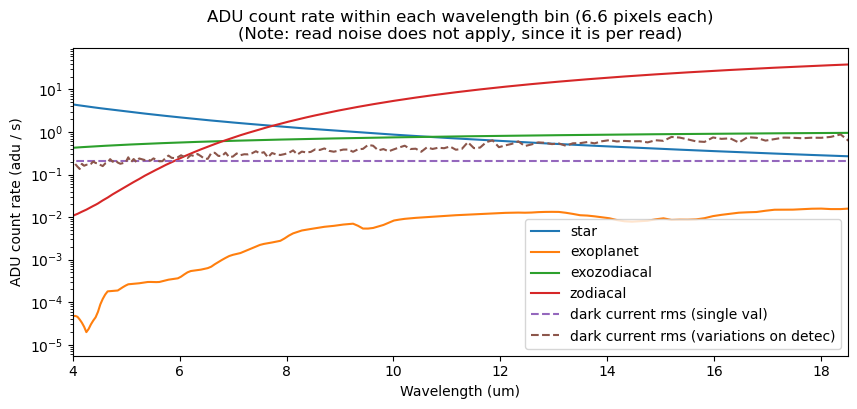

In [ ]:
# convert back to per-second quantities

t_int = 6667 * u.second # integration time
star_adu_rate = channel_dark_3['astro_star_flux_adu_for_wavel_bin_and_integration_tot'] / t_int
exoplanet_adu_rate = channel_dark_3['astro_exoplanet_model_10pc_flux_adu_for_wavel_bin_and_integration_tot'] / t_int
exozodiacal_adu_rate = channel_dark_3['astro_exozodiacal_flux_adu_for_wavel_bin_and_integration_tot'] / t_int
zodiacal_adu_rate = channel_dark_3['astro_zodiacal_flux_adu_for_wavel_bin_and_integration_tot'] / t_int
dark_current_rms = channel_dark_3['instrum_dark_current_rms_for_wavel_bin_and_integration_adu_tot'] / np.sqrt(t_int)

# just a stand-in for dark current fluctuation: some slope and noise on top of that
rng = np.random.default_rng(42)
dark_current_rms_variable = 0.2 * dark_current_rms * channel_dark_3['wavel_bin_center'] * (1 + rng.normal(0, 0.1, size=len(dark_current_rms)))

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(channel_dark_3['wavel_bin_center'], star_adu_rate, label='star')
ax.plot(channel_dark_3['wavel_bin_center'], exoplanet_adu_rate, label='exoplanet')
ax.plot(channel_dark_3['wavel_bin_center'], exozodiacal_adu_rate, label='exozodiacal')
ax.plot(channel_dark_3['wavel_bin_center'], zodiacal_adu_rate, label='zodiacal')
ax.plot(channel_dark_3['wavel_bin_center'], dark_current_rms, linestyle='--', label='dark current rms (single val)')
ax.plot(channel_dark_3['wavel_bin_center'], dark_current_rms_variable, linestyle='--', label='dark current rms (variations on detec)')


ax.set_xlim([4,18.5])
ax.set_yscale('log')
plt.xlabel(f"Wavelength ({channel_dark_3['wavel_bin_center'].unit})")
plt.ylabel(f"ADU count rate ({star_adu_rate.unit})")
plt.legend()
plt.title('ADU count rate within each wavelength bin (6.6 pixels each)\n(Note: read noise does not apply, since it is per read)')
plt.show()